<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

Accompanying Worksheets to Class Notes, also printed in [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0GJD4DNNY).

# Worksheet 18: Data Processing and Interpolation

- Clean a data set: flag missing points, convert units;
- Fit a linear model using least squares; compute residuals;
- Interpolate a data set towards uniform spacing;
- Plot data + fit + residuals; interpret parameters.

In [ ]:
import pandas as pd
from scipy import interpolate 
import numpy as np
import matplotlib.pyplot as plt

# Data Processing and Interpolation

This notebook introduces a standard computational physics workflow:

1. Clean a data set by flagging missing values and converting units.
2. Fit a linear model using least squares.
3. Compute and interpret residuals.
4. Interpolate the data onto a uniformly spaced grid.
5. Plot the data, fit, and residuals.

You could use the [PhyPhox App](https://phyphox.org/) to record the motion of an object. The example below uses a small position-versus-time data set with missing entries and irregular sampling.


## Learning goals

By the end of this notebook, you should be able to:

- identify and handle missing data using `NaN` and Boolean masks,
- convert experimental data into consistent SI units,
- perform a least-squares linear fit,
- calculate residuals and use them to assess model quality,
- interpolate irregularly sampled data onto a uniform grid,
- produce clear plots for analysis and interpretation.

## Physical scenario

Suppose a tennis ball moves approximately at constant velocity along a track. A motion sensor records time in **milliseconds** and position in **centimeters**, but:

- the sampling times are not perfectly uniform,
- one of the position measurements is missing,
- we want to analyze the motion in **SI units**.

For constant-velocity motion, the expected model is

$$
x(t) = vt + x_0,
$$

where:

- $v$ is the velocity,
- $x_0$ is the initial position.

In [2]:
# Raw experimental data
# Time is recorded in milliseconds
# Position is recorded in centimeters


<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 0: Load and Explore

Load the data set (`"tennis_ball_data.csv"`) using `read_csv()` from Pandas: 

- use `info()` to see a summary
- use `head()` to view the first few rows
- use `describe()` to find any outliers
- find all years for which the population is over 125 million use `np.where` and `iloc`

```
# Loading a Dataframe from a URL or filename
df = pd.read_csv(url)
```

</div>

In [ ]:
# Load the data and explore it (see below for descriptions)


## Data Processing  

Data processing is a fundamental step in data science, and Python provides excellent tools to handle it. In general, data is available from in comma-separated text files (*CSV*), GitHub repositories, or general websites through scraping. The library `pandas` is particularly useful for data importing and cleaning. Pandas can load CSV files, handle missing data values, transform data, apply scaling, and remove duplicates. Use the `df = pd.read_csv()` function to import data into a type called `DataFrame` (df), which can be easily viewed. More advanced imports use the comment attribute to ignore certain lines, or skip rows, if the file includes additional header information. \index{package!pandas}

The first argument of `pd.read_csv(filepath)` can be a local filename or a URL. If an error occurs while reading the file, it is often because the header is not located in the first row. In such cases, we need to specify which row contains the column names. The argument `header=61` indicates that the header is located in row 61.


| usage                                | description                          |
|:------------------------------------ |:------------------------------------ |
| `df.head(n=5)`  / `df.tail()`        | View first *n* rows             |
| `df.info()`                          | Print a compact summary              |
| `df.describe()`                      | Statistics and outliers              |
| `df.groupby(keys).agg(...)`          | Splits data into groups              |
| `df.merge()`   | Join two DataFrames (SQL)      |
| `df.loc[row, col]` | Filter, slice, update                |

: Common methods in `pandas` for a DataFrame `df`.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">



## Step 1: Inspect and clean the data

A missing measurement should **not** be replaced with zero, because zero is a physically meaningful value. Instead, we represent missing data using `NaN` and create a mask that tells us which entries are valid.

We also convert the data into SI units:

- milliseconds $\to$ seconds,
- centimeters $\to$ meters.

In [15]:
# Create new columns for Time and Position in SI units (seconds and meters, respectively)
df  

,Time (ms),Position (cm),Position (m)
0,0.0,2.1,0.021
1,120.0,NaN,NaN
2,260.0,7.8,0.078
3,390.0,11.4,0.114
4,510.0,14.9,0.149
5,650.0,18.2,0.182
6,780.0,21.0,0.210
7,920.0,24.6,0.246


## Dropping Non Values

Non values can be dropped from the data frame with `dropna()`. You can also drop NaN values from specific columns only, if needed.

In [ ]:
# Print a Data Frame with Valid Entries in SI units


,Time (ms),Position (cm),Position (m)
0,0.0,2.1,0.021
2,260.0,7.8,0.078
3,390.0,11.4,0.114
4,510.0,14.9,0.149
5,650.0,18.2,0.182
6,780.0,21.0,0.210
7,920.0,24.6,0.246


### Checkpoint

- Are all entries valid?
- Are the units physically consistent?
- Are we keeping a clear distinction between *raw* and *processed* data?
- Does the data set make sense?

==>  add your discussion



<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 2: Make an initial plot of the cleaned data

Before fitting, it is good practice to visualize the valid data points.

In [ ]:
fig, ax = plt.subplots()
# label the axes
 
plt.show()

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 3: Fit a linear model using least squares

We assume the motion is approximately linear in time and use Newton's 1st law as a model:

$$
x(t) = vt + x_0.
$$

Using `numpy.polyfit` with degree 1 gives the least-squares best-fit slope and intercept.

- The **slope** corresponds to the velocity $v$.
- The **intercept** corresponds to the initial position $x_0$.

==> Find $v$ and $x_0$.

In [20]:
# Add code with the best-fit line parameters here
v = np.nan
x0 = np.nan

print(f"Best-fit slope (velocity): {v:.5f} m/s")
print(f"Best-fit intercept (initial position): {x0:.5f} m")

Best-fit slope (velocity): nan m/s
Best-fit intercept (initial position): nan m


<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 4: Compute residuals

The residual at each measured point is

$$ 
 r_i = x_i - \hat{x}_i,
$$ 

where $x_i$ is the measured position and $\hat{x}_i$ is the model prediction.

Residuals help us judge whether the linear model is appropriate. If the residuals are small and patternless, the model is likely reasonable.

In [21]:
# find all the residuals values; you can also compute chi-squared (optional)

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 5: Interpolate the data onto a uniform grid

The original measurements were not taken at perfectly even time intervals. Some later numerical methods work best with uniformly spaced samples.

Construct a uniformly spaced time grid and interpolate the valid data onto that grid using linear interpolation with 10 data points.

Use `np.interp(x_new, x_data, y_data)` to return the new `y_new`.

In [22]:
# Create a uniformly spaced time grid


<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 6: Plot the data, fit, and interpolated values

This figure compares:

- the original valid data,
- the least-squares best-fit line,
- the interpolated values on a uniform grid.

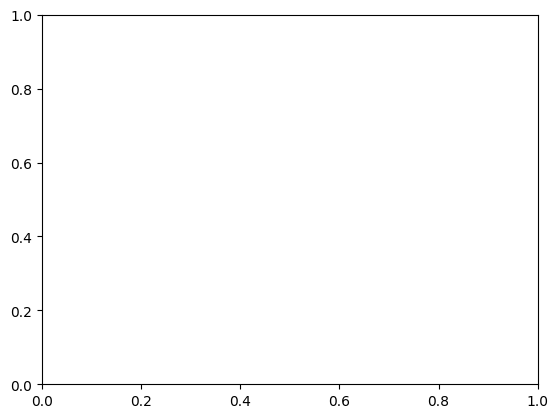

In [26]:
# Smooth line for the fitted model
fig, ax = plt.subplots()

# your code to plot the data and the best-fit line here

...
plt.show()

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box"> 

## Step 7: Plot the residuals

Residual plots are one of the most useful diagnostics in data analysis. A good linear model should leave residuals scattered around zero without a clear systematic trend.

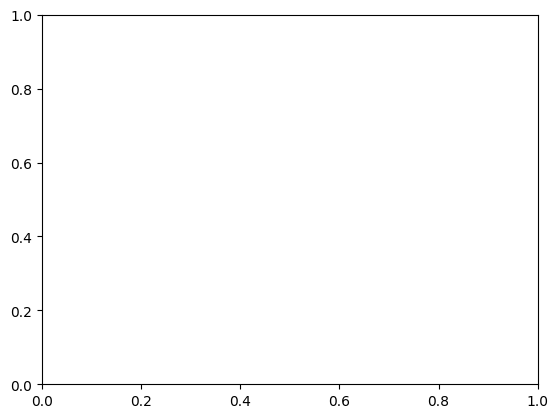

In [30]:
fig, ax = plt.subplots() 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Interpretation of the fit parameters

When you analyze a fit, do not stop at the numerical values. Always ask:

- Do the units make sense for the fit values?
- Is the slope physically reasonable?
- Does the intercept correspond to a meaningful starting point?
- Do the residuals support the chosen model?
- What have you learned?

==> YOUR DISCUSSION

## Optional  

Try one or more of the following:

- Add a second missing point and adapt the analysis.
- Replace the approximately linear data with slightly curved data and see how the residual plot changes.
- Compare interpolation with simply evaluating the fitted line on the uniform grid.
- Compute the root-mean-square residual.

In [ ]:
# Optional workspace cell for your own analysis
# Add your code here.